# Exploratory Data Analysis


## Business Understanding

The objective of this project is to predict customer attrition/churn.

From a business perspective, the goal is to help the company identify customers who are likely to leave, so that retention actions can be prioritized.

The machine learning problem can be framed as a binary classification task:
- Positive class: customer likely to churn / attrited customer
- Negative class: existing or retained customer

The model could be used as a decision-support tool to prioritize retention campaigns.

## Dataset overview 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/salma/Documents/Churning-customers/data/raw/BankChurners.csv")

df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  str    
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                                      

In [11]:
df_processed=df.drop(columns=["Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1","Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"])

In [22]:
print(df.describe().round(2))

          CLIENTNUM  Customer_Age  Dependent_count  Months_on_book  \
count  1.012700e+04      10127.00         10127.00        10127.00   
mean   7.391776e+08         46.33             2.35           35.93   
std    3.690378e+07          8.02             1.30            7.99   
min    7.080821e+08         26.00             0.00           13.00   
25%    7.130368e+08         41.00             1.00           31.00   
50%    7.179264e+08         46.00             2.00           36.00   
75%    7.731435e+08         52.00             3.00           40.00   
max    8.283431e+08         73.00             5.00           56.00   

       Total_Relationship_Count  Months_Inactive_12_mon  \
count                  10127.00                10127.00   
mean                       3.81                    2.34   
std                        1.55                    1.01   
min                        1.00                    0.00   
25%                        3.00                    2.00   
50%            

## Missing values,  duplicates and Unknown 

In [18]:
overview = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
    "missing_pct": round(df.isna().mean() * 100, 2)
})

overview

,column,dtype,n_unique,n_missing,missing_pct
CLIENTNUM,CLIENTNUM,int64,10127,0,0.0
Attrition_Flag,Attrition_Flag,str,2,0,0.0
Customer_Age,Customer_Age,int64,45,0,0.0
Gender,Gender,str,2,0,0.0
Dependent_count,Dependent_count,int64,6,0,0.0
Education_Level,Education_Level,str,7,0,0.0
Marital_Status,Marital_Status,str,4,0,0.0
Income_Category,Income_Category,str,6,0,0.0
Card_Category,Card_Category,str,4,0,0.0
Months_on_book,Months_on_book,int64,44,0,0.0


In [16]:
df_processed.duplicated().sum()

np.int64(0)

Vérifier les valeurs "unknown":

In [23]:
unknown_counts = {}

for col in df.select_dtypes(include="object").columns:
    unknown_counts[col] = (df[col] == "Unknown").sum()

unknown_counts = pd.Series(unknown_counts).sort_values(ascending=False)
unknown_counts

/var/folders/c6/cw1kzdh92sv13x0v2w4bb_y40000gn/T/ipykernel_16204/653528271.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


Education_Level    1519
Income_Category    1112
Marital_Status      749
Attrition_Flag        0
Gender                0
Card_Category         0
dtype: int64

In [33]:
for col in ["Education_Level", "Income_Category", "Marital_Status"]:
    churn_rate_by_category = df_processed.groupby(col)["Churn"].mean().sort_values(ascending=False)
    print(f"\nChurn rate by {col}:")
    display(churn_rate_by_category)


Churn rate by Education_Level:


Education_Level
Doctorate        0.210643
Post-Graduate    0.178295
Unknown          0.168532
Uneducated       0.159381
Graduate         0.155691
College          0.152024
High School      0.152012
Name: Churn, dtype: float64


Churn rate by Income_Category:


Income_Category
$120K +           0.173315
Less than $40K    0.171862
Unknown           0.168165
$80K - $120K      0.157655
$40K - $60K       0.151397
$60K - $80K       0.134807
Name: Churn, dtype: float64


Churn rate by Marital_Status:


Marital_Status
Unknown     0.172230
Single      0.169414
Divorced    0.161765
Married     0.151269
Name: Churn, dtype: float64

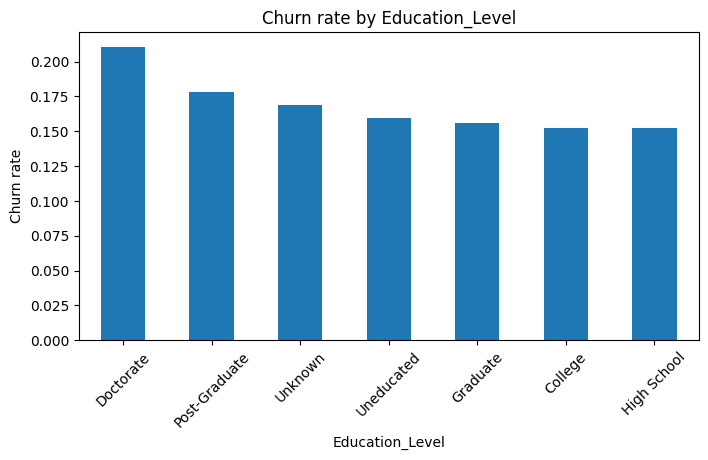

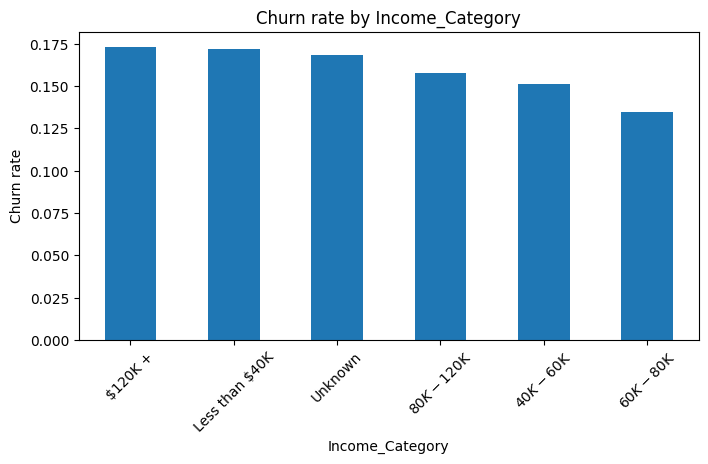

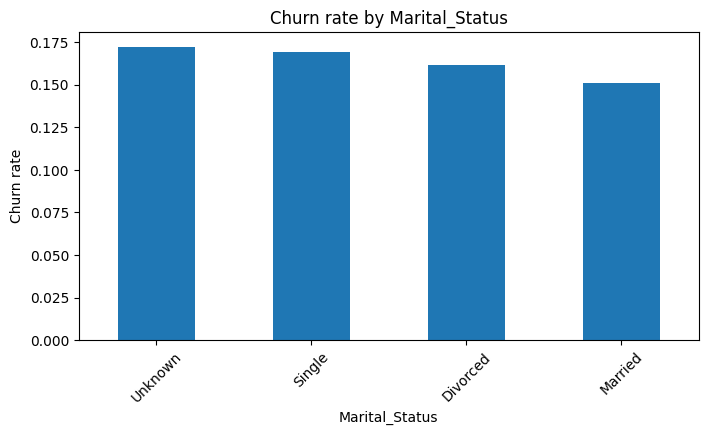

In [34]:
for col in ["Education_Level", "Income_Category", "Marital_Status"]:
    churn_rate_by_category = df_processed.groupby(col)["Churn"].mean().sort_values(ascending=False)

    plt.figure(figsize=(8, 4))
    churn_rate_by_category.plot(kind="bar")
    plt.title(f"Churn rate by {col}")
    plt.ylabel("Churn rate")
    plt.xticks(rotation=45)
    plt.show()

## Target Analysis

In [27]:
target = "Attrition_Flag"
df[target].value_counts()

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

In [28]:
df[target].value_counts(normalize=True) * 100

Attrition_Flag
Existing Customer    83.934038
Attrited Customer    16.065962
Name: proportion, dtype: float64

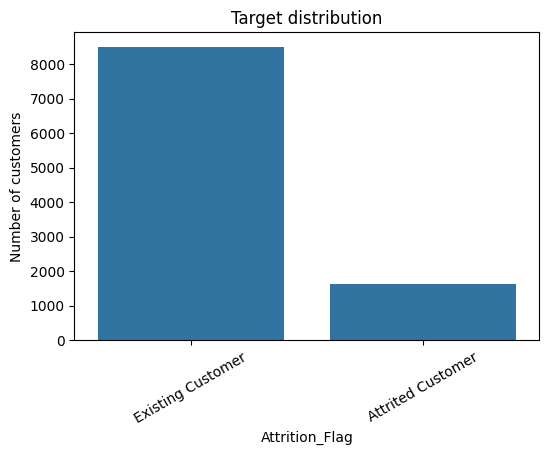

In [29]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target)
plt.title("Target distribution")
plt.xlabel(target)
plt.ylabel("Number of customers")
plt.xticks(rotation=30)
plt.show()

In [30]:

df_processed["Churn"] = df_processed[target].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

df_processed["Churn"].value_counts()

Churn
0    8500
1    1627
Name: count, dtype: int64

In [32]:
df_processed.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


In [31]:
churn_rate = df_processed["Churn"].mean()
print(f"Churn rate: {churn_rate:.2%}")

Churn rate: 16.07%


## Analyse des variables numériques 

In [25]:
num_cols = df_processed.select_dtypes(include=["int64", "float64"]).columns.tolist()

num_cols

['CLIENTNUM',
 'Customer_Age',
 'Dependent_count',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio']

In [35]:
cols_to_remove = ["CLIENTNUM", "Churn"]

num_cols = [col for col in num_cols if col not in cols_to_remove]

num_cols

['Customer_Age',
 'Dependent_count',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio']

In [26]:
df_processed[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,708082083.0,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,26.0,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.0,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,13.0,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.0,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1438.3,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.0,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.0,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


### Histogrammes

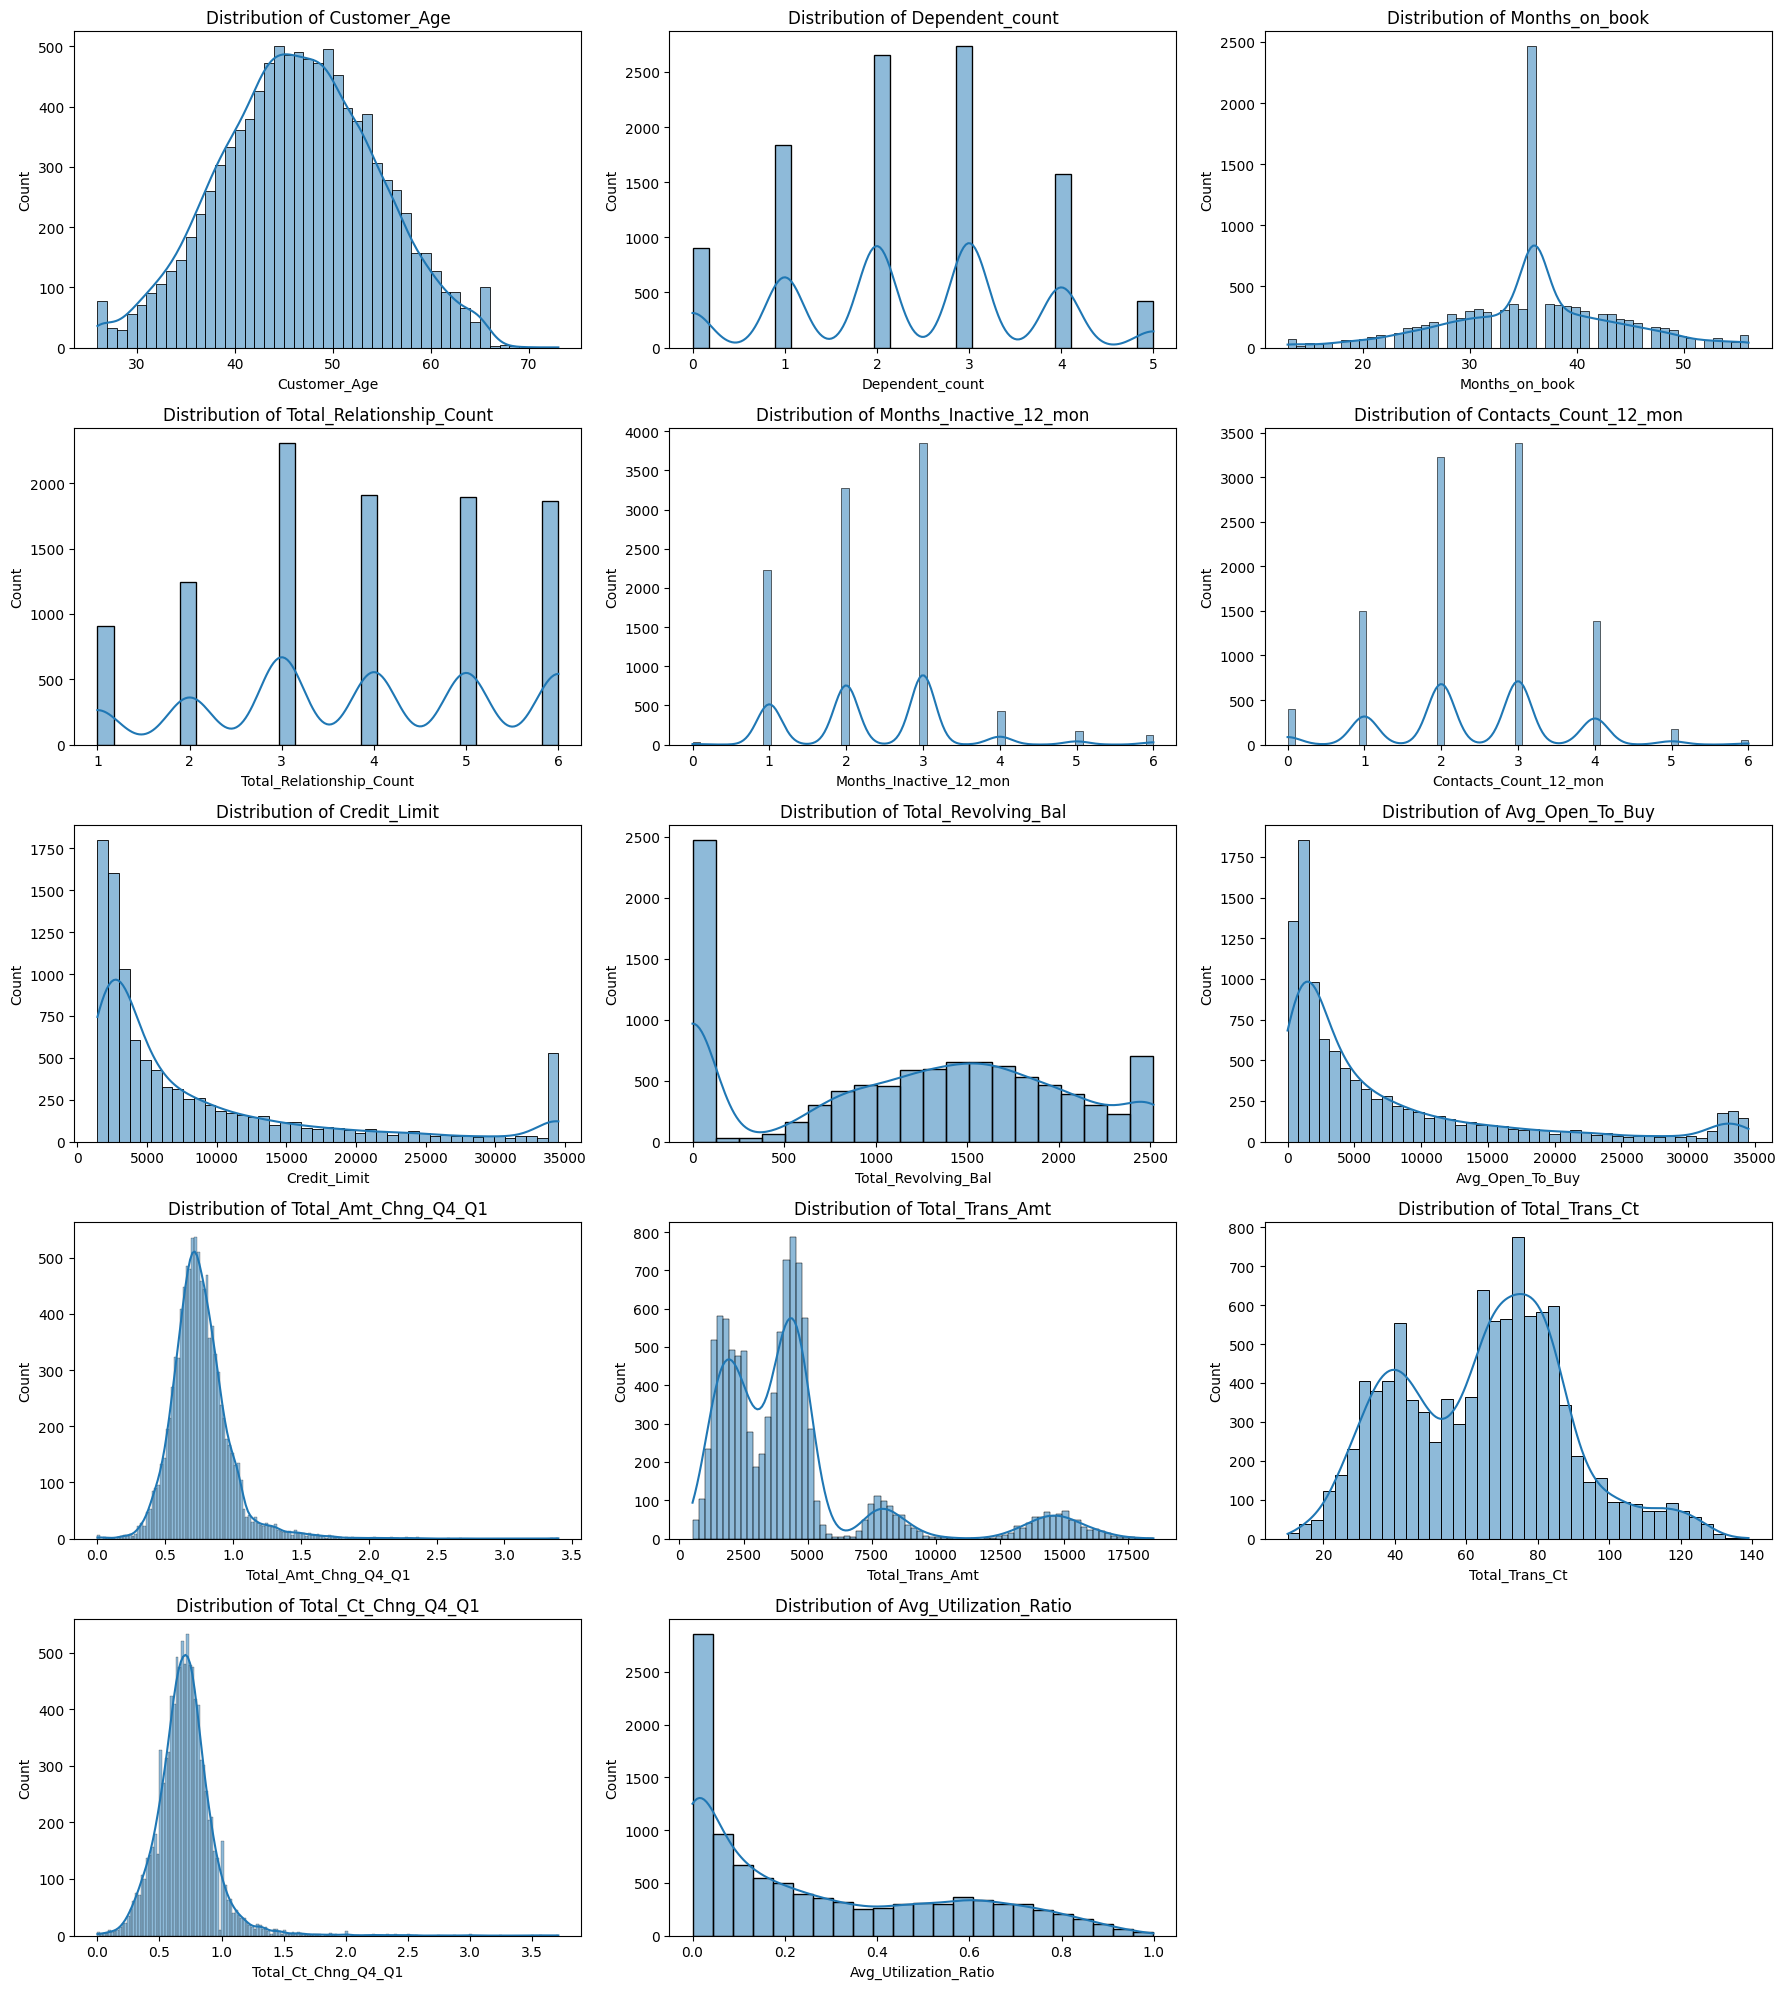

In [55]:
import math

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df_processed,
        x=col,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Supprimer les graphiques vides s'il y en a
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Boxplots 

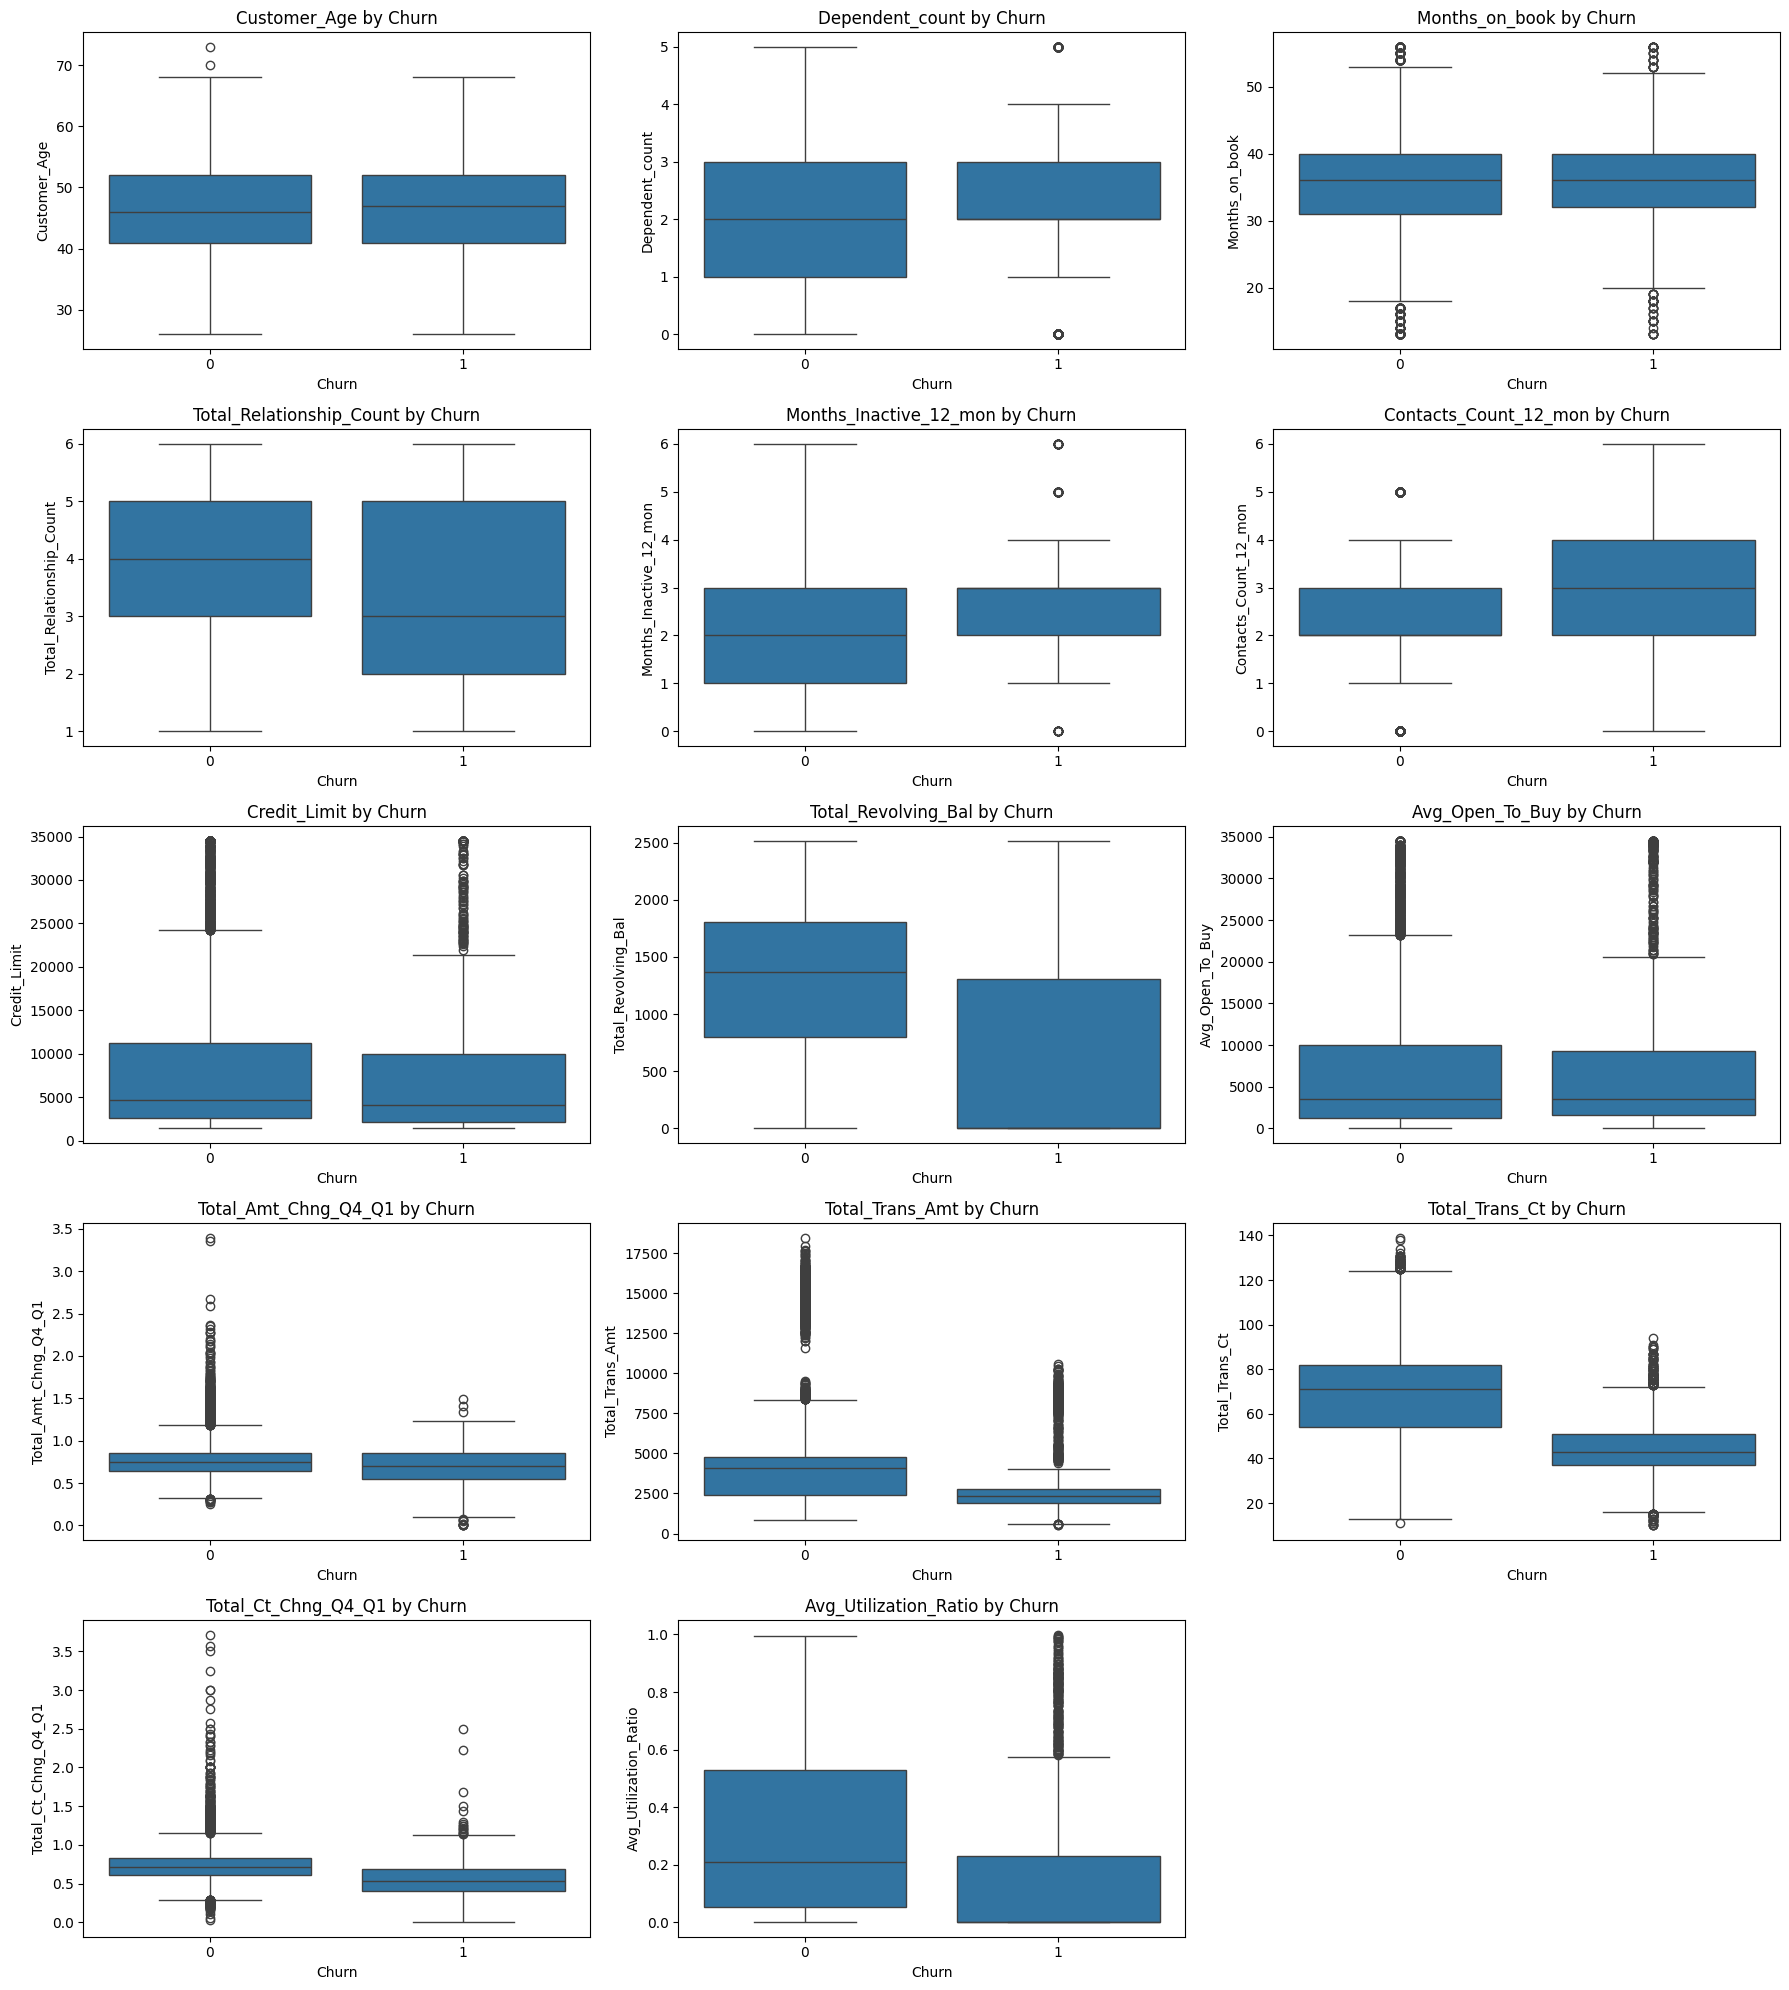

In [56]:
import math

# Optionnel : enlever les colonnes qu'on ne veut pas afficher
num_cols_to_plot = [col for col in num_cols if col not in ["CLIENTNUM", "Churn"]]

n_cols = 3
n_rows = math.ceil(len(num_cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(num_cols_to_plot):
    sns.boxplot(
        data=df_processed,
        x="Churn",
        y=col,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} by Churn")
    axes[i].set_xlabel("Churn")
    axes[i].set_ylabel(col)

# Supprimer les graphiques vides s'il y en a
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Boxplots by churn - Key insights

The boxplots show that some variables differ more clearly between existing and attrited customers.

- `Customer_Age` and `Months_on_book` show very similar distributions across both groups, suggesting limited individual predictive power.
- `Total_Relationship_Count` is lower among attrited customers, suggesting that customers with fewer banking relationships are more likely to churn.
- `Months_Inactive_12_mon` is slightly higher among attrited customers, indicating that inactivity may be a warning signal.
- `Contacts_Count_12_mon` is higher among attrited customers, which may reflect dissatisfaction or unresolved issues.
- `Total_Revolving_Bal` is noticeably lower among attrited customers, suggesting that lower credit usage is associated with churn.
- `Credit_Limit` and `Avg_Open_To_Buy` show many high-value outliers but limited separation between churn groups.

### Corrélations

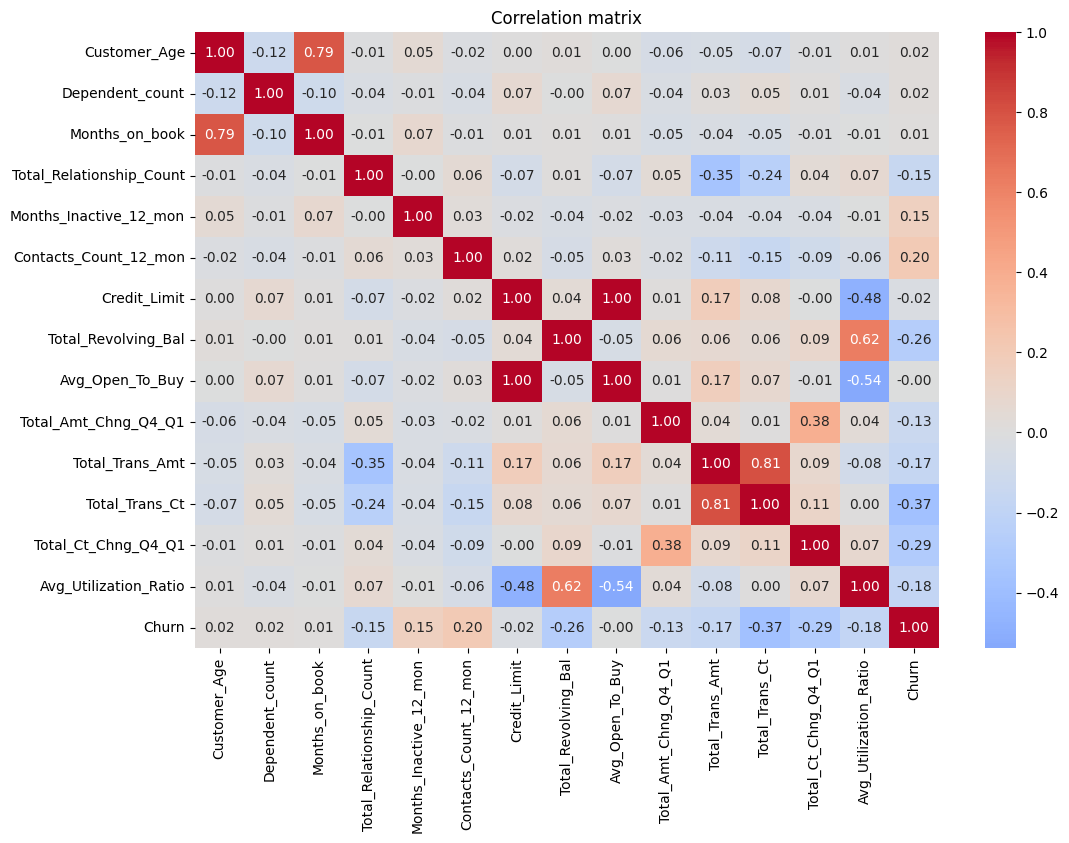

In [39]:
corr = df_processed[num_cols + ["Churn"]].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f",  cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

In [40]:
corr_with_target = corr["Churn"].sort_values(ascending=False)
corr_with_target

Churn                       1.000000
Contacts_Count_12_mon       0.204491
Months_Inactive_12_mon      0.152449
Dependent_count             0.018991
Customer_Age                0.018203
Months_on_book              0.013687
Avg_Open_To_Buy            -0.000285
Credit_Limit               -0.023873
Total_Amt_Chng_Q4_Q1       -0.131063
Total_Relationship_Count   -0.150005
Total_Trans_Amt            -0.168598
Avg_Utilization_Ratio      -0.178410
Total_Revolving_Bal        -0.263053
Total_Ct_Chng_Q4_Q1        -0.290054
Total_Trans_Ct             -0.371403
Name: Churn, dtype: float64

## Categorical variables analysis 

In [41]:
cat_cols = df_processed.select_dtypes(include="object").columns.tolist()

cat_cols

/var/folders/c6/cw1kzdh92sv13x0v2w4bb_y40000gn/T/ipykernel_16204/3502117267.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_processed.select_dtypes(include="object").columns.tolist()


['Attrition_Flag',
 'Gender',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category']

In [42]:
cat_cols = [col for col in cat_cols if col != target]

cat_cols

['Gender',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category']

In [43]:
df_processed[cat_cols].nunique().sort_values()

Gender             2
Marital_Status     4
Card_Category      4
Income_Category    6
Education_Level    7
dtype: int64

### Distributions des catégories 

In [44]:
for col in cat_cols:
    print(f"\nColumn: {col}")
    display(df_processed[col].value_counts(dropna=False))


Column: Gender


Gender
F    5358
M    4769
Name: count, dtype: int64


Column: Education_Level


Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64


Column: Marital_Status


Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64


Column: Income_Category


Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64


Column: Card_Category


Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64

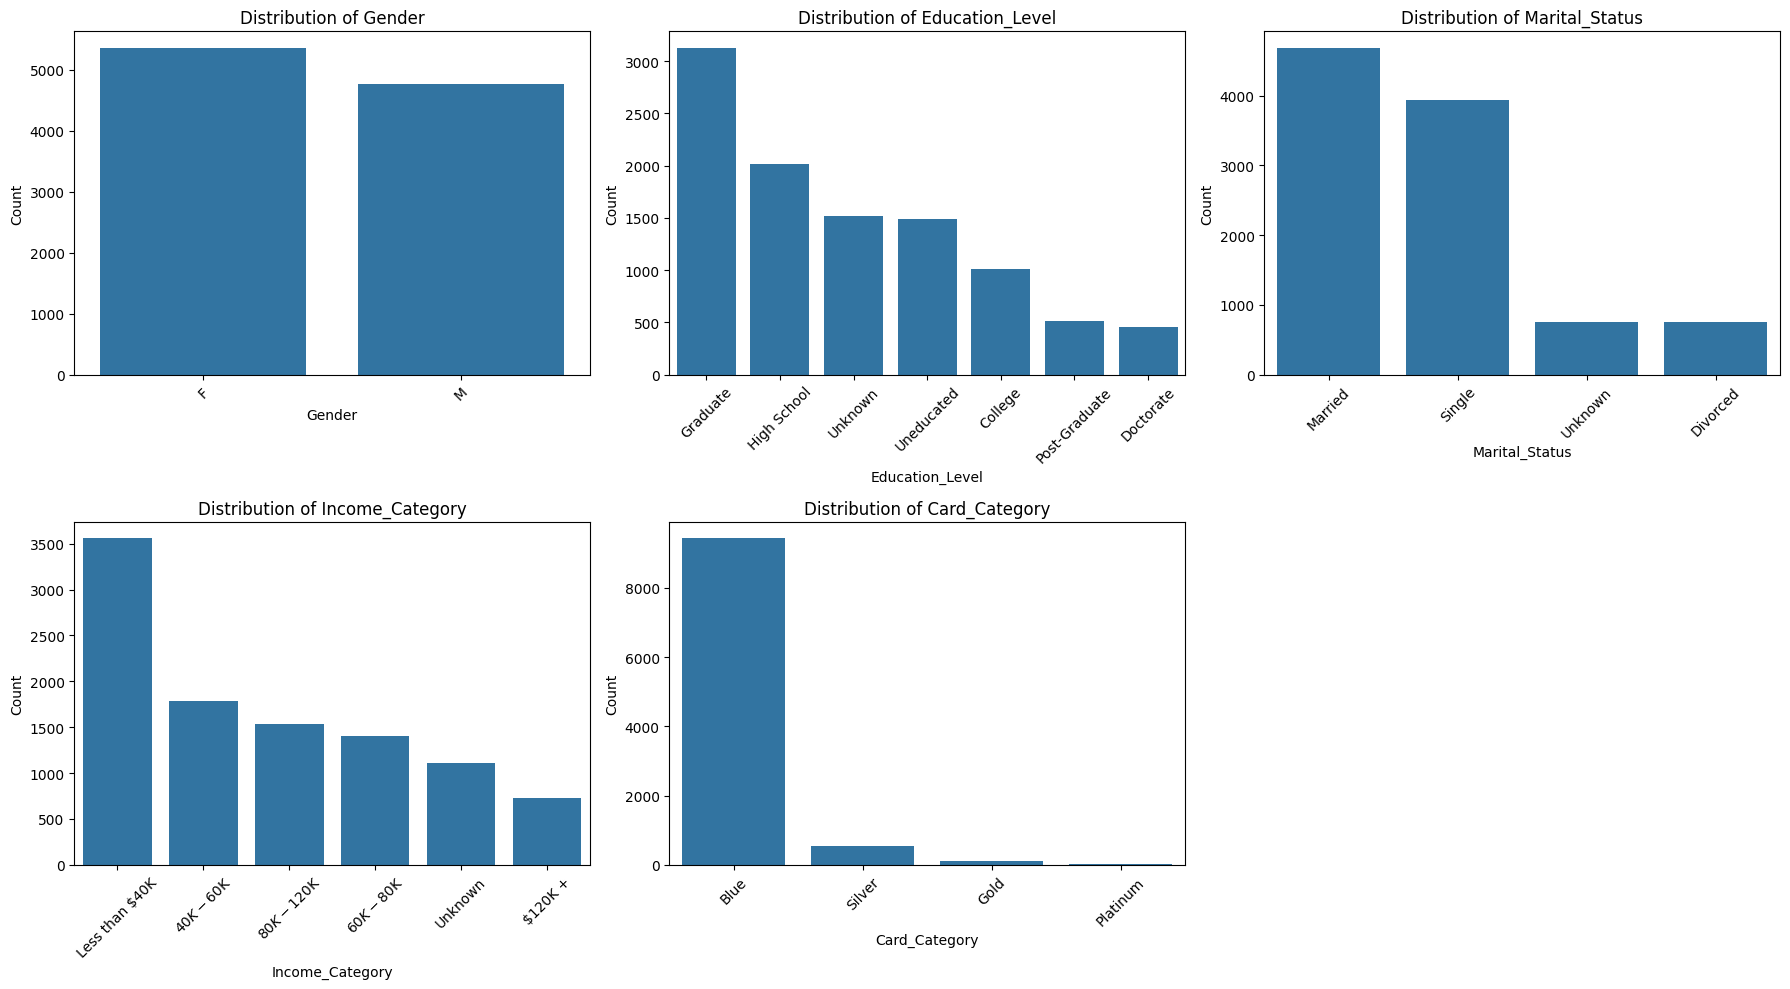

In [54]:
import math

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df_processed,
        x=col,
        order=df_processed[col].value_counts().index,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

# Supprimer les graphiques vides s'il y en a
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Taux de churn par catégorie 

In [46]:
for col in cat_cols:
    churn_by_cat = df_processed.groupby(col)["Churn"].mean().sort_values(ascending=False)
    print(f"\nChurn rate by {col}:")
    display(churn_by_cat)


Churn rate by Gender:


Gender
F    0.173572
M    0.146152
Name: Churn, dtype: float64


Churn rate by Education_Level:


Education_Level
Doctorate        0.210643
Post-Graduate    0.178295
Unknown          0.168532
Uneducated       0.159381
Graduate         0.155691
College          0.152024
High School      0.152012
Name: Churn, dtype: float64


Churn rate by Marital_Status:


Marital_Status
Unknown     0.172230
Single      0.169414
Divorced    0.161765
Married     0.151269
Name: Churn, dtype: float64


Churn rate by Income_Category:


Income_Category
$120K +           0.173315
Less than $40K    0.171862
Unknown           0.168165
$80K - $120K      0.157655
$40K - $60K       0.151397
$60K - $80K       0.134807
Name: Churn, dtype: float64


Churn rate by Card_Category:


Card_Category
Platinum    0.250000
Gold        0.181034
Blue        0.160979
Silver      0.147748
Name: Churn, dtype: float64

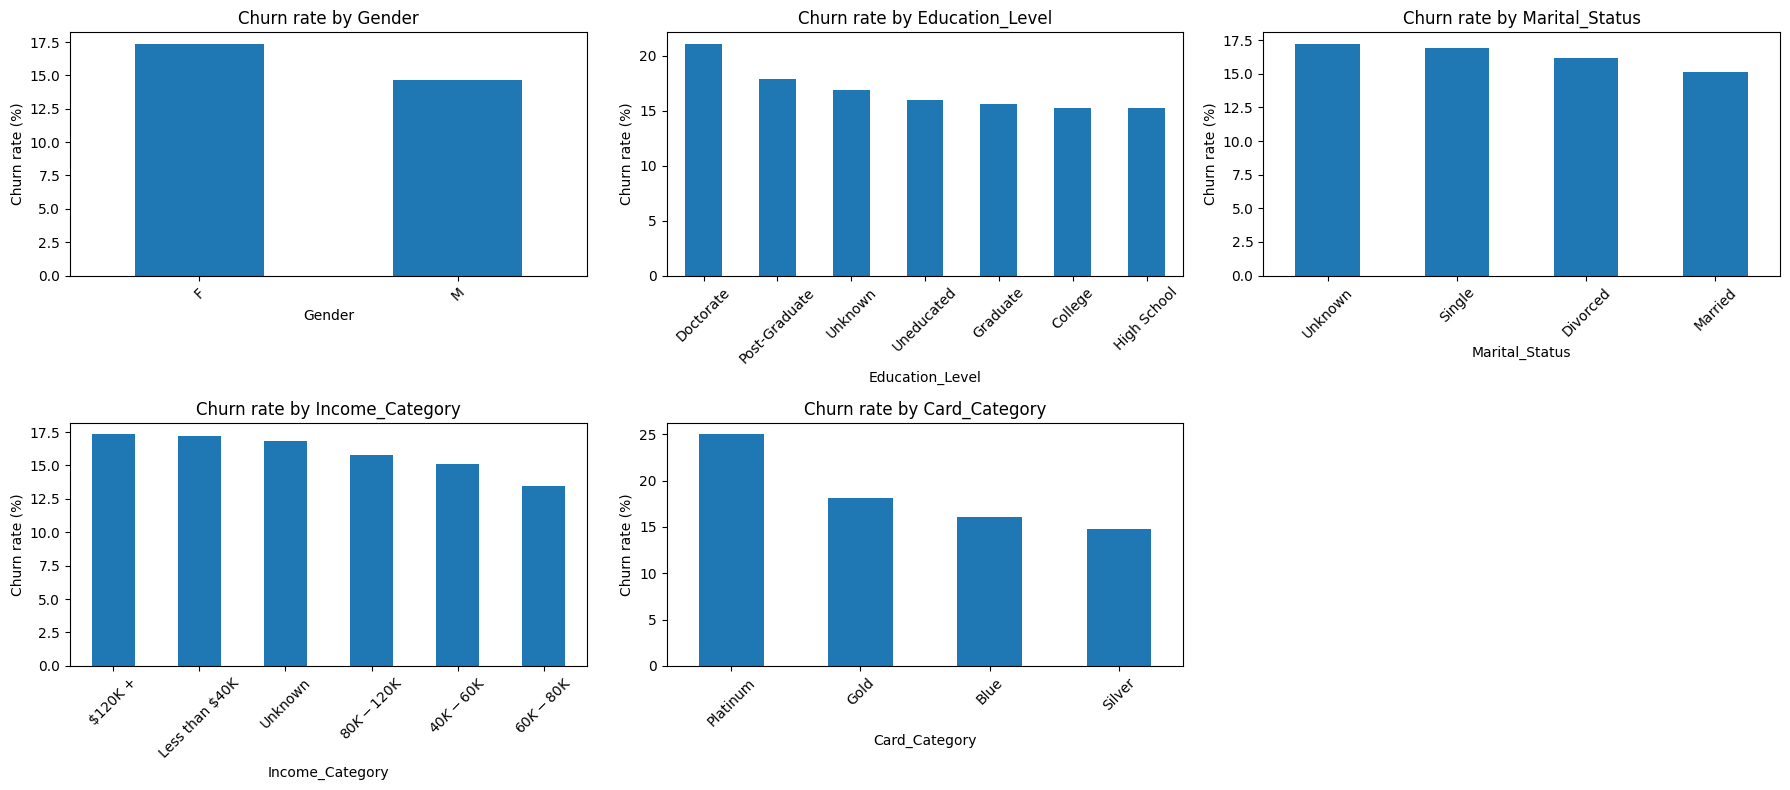

In [57]:
import math

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))

axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_by_cat = df_processed.groupby(col)["Churn"].mean().sort_values(ascending=False) * 100

    churn_by_cat.plot(
        kind="bar",
        ax=axes[i]
    )

    axes[i].set_title(f"Churn rate by {col}")
    axes[i].set_ylabel("Churn rate (%)")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Key insights 

In [50]:
print(f"Number of rows: {df_processed.shape[0]}")
print(f"Number of columns after cleaning: {df_processed.shape[1]}")
print(f"Churn rate: {df_processed['Churn'].mean():.2%}")
print(f"Number of duplicated rows: {df_processed.duplicated().sum()}")

Number of rows: 10127
Number of columns after cleaning: 22
Churn rate: 16.07%
Number of duplicated rows: 0


In [51]:
corr_with_churn = df_processed.select_dtypes(include=["int64", "float64"]).corr()["Churn"].sort_values(key=abs, ascending=False)

corr_with_churn.head(10)

Churn                       1.000000
Total_Trans_Ct             -0.371403
Total_Ct_Chng_Q4_Q1        -0.290054
Total_Revolving_Bal        -0.263053
Contacts_Count_12_mon       0.204491
Avg_Utilization_Ratio      -0.178410
Total_Trans_Amt            -0.168598
Months_Inactive_12_mon      0.152449
Total_Relationship_Count   -0.150005
Total_Amt_Chng_Q4_Q1       -0.131063
Name: Churn, dtype: float64

## 8. Key insights

- The dataset contains customer-level information for a churn prediction use case.
- The target variable is `Attrition_Flag`, transformed into a binary variable `Churn`.
- The churn rate is around XX%, meaning the dataset is moderately imbalanced.
- No major missing values were detected / Some variables contain missing or unknown values.
- The columns starting with `Naive_Bayes_Classifier...` were removed because they represent potential data leakage.
- Some variables seem associated with churn and should be investigated further during modeling.
- The next step is to prepare the data, encode categorical variables, split the dataset, and build a baseline classification model.

# Preprocessing

In [65]:
df_model=df_processed.copy()
df_model=df_processed.drop(columns=["CLIENTNUM","Attrition_Flag"])

df_model.head()

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0
1,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0
2,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0
3,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0
4,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0


In [67]:
# 6. Encode categorical variables
df_model_encoded = pd.get_dummies(df_model, drop_first=True, dtype=int)

df_model_encoded.head()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,...,Marital_Status_Single,Marital_Status_Unknown,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,45,3,39,5,1,3,12691.0,777,11914.0,1.335,...,0,0,0,1,0,0,0,0,0,0
1,49,5,44,6,1,2,8256.0,864,7392.0,1.541,...,1,0,0,0,0,1,0,0,0,0
2,51,3,36,4,1,0,3418.0,0,3418.0,2.594,...,0,0,0,0,1,0,0,0,0,0
3,40,4,34,3,4,1,3313.0,2517,796.0,1.405,...,0,1,0,0,0,1,0,0,0,0
4,40,3,21,5,1,0,4716.0,0,4716.0,2.175,...,0,0,0,1,0,0,0,0,0,0


### Séparer X et Y 

In [68]:
X = df_model_encoded.drop(columns=["Churn"])
y = df_model_encoded["Churn"]

In [69]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Churn rate:", y.mean())

X shape: (10127, 32)
y shape: (10127,)
Churn rate: 0.1606596227905599


### Train/Test Split 


In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
print("Train churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Train churn rate: 0.1607208986544871
Test churn rate: 0.16041461006910168


## Logistic Regression

In [76]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [77]:
import pandas as pd

coefficients = log_reg_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

coef_df.head(20)

,feature,coefficient,abs_coefficient
11,Total_Trans_Ct,-3.024478,3.024478
10,Total_Trans_Amt,1.790733,1.790733
12,Total_Ct_Chng_Q4_Q1,-0.606237,0.606237
7,Total_Revolving_Bal,-0.604718,0.604718
3,Total_Relationship_Count,-0.601669,0.601669
5,Contacts_Count_12_mon,0.579679,0.579679
4,Months_Inactive_12_mon,0.557786,0.557786
14,Gender_M,-0.402141,0.402141
27,Income_Category_Less than $40K,-0.226488,0.226488
24,Income_Category_$40K - $60K,-0.214332,0.214332


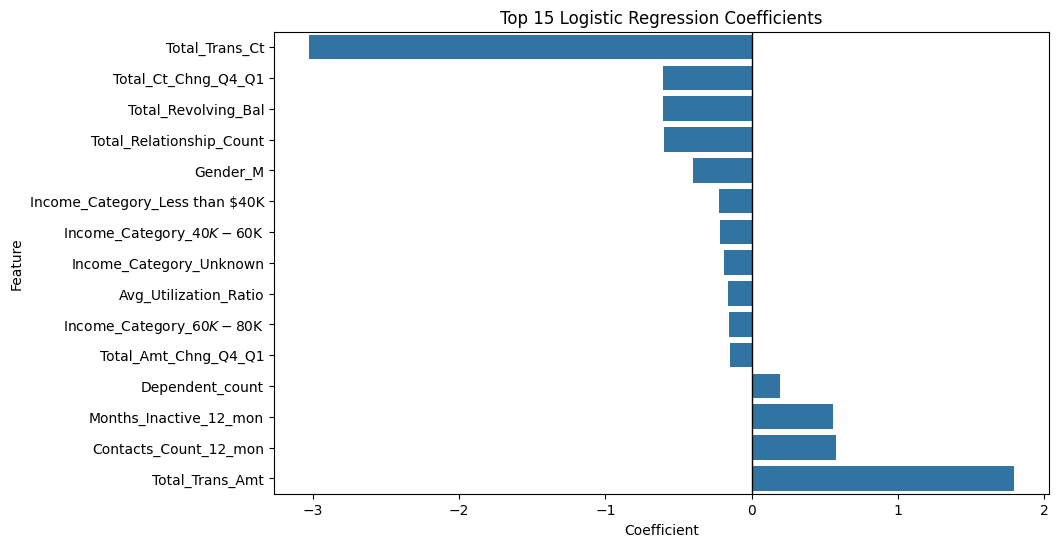

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

top_coef = coef_df.head(15).sort_values("coefficient")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_coef,
    x="coefficient",
    y="feature"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Top 15 Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

In [81]:
log_reg_results = evaluate_model(
    log_reg_pipeline,
    X_train,
    y_train,
    X_test,
    y_test
)

log_reg_results

,metric,train,test
0,accuracy,0.850759,0.854886
1,precision,0.521719,0.530938
2,recall,0.857911,0.818462
3,f1_score,0.648853,0.644068
4,roc_auc,0.928998,0.920669


### Random Forest 

In [79]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1701
           1       0.93      0.74      0.82       325

    accuracy                           0.95      2026
   macro avg       0.94      0.86      0.90      2026
weighted avg       0.95      0.95      0.95      2026

ROC-AUC: 0.9845511689956135


In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_proba_train = model.predict_proba(X_train)[:, 1]
    
    y_pred_test = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)[:, 1]
    
    results = {
        "metric": ["accuracy", "precision", "recall", "f1_score", "roc_auc"],
        "train": [
            accuracy_score(y_train, y_pred_train),
            precision_score(y_train, y_pred_train),
            recall_score(y_train, y_pred_train),
            f1_score(y_train, y_pred_train),
            roc_auc_score(y_train, y_proba_train)
        ],
        "test": [
            accuracy_score(y_test, y_pred_test),
            precision_score(y_test, y_pred_test),
            recall_score(y_test, y_pred_test),
            f1_score(y_test, y_pred_test),
            roc_auc_score(y_test, y_proba_test)
        ]
    }
    
    return pd.DataFrame(results)

evaluate_model(rf, X_train, y_train, X_test, y_test)

,metric,train,test
0,accuracy,1.0,0.949161
1,precision,1.0,0.933594
2,recall,1.0,0.735385
3,f1_score,1.0,0.822719
4,roc_auc,1.0,0.984551


## feature importance RF 

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(20)

,feature,importance
11,Total_Trans_Ct,0.204431
10,Total_Trans_Amt,0.191837
7,Total_Revolving_Bal,0.101196
12,Total_Ct_Chng_Q4_Q1,0.098652
13,Avg_Utilization_Ratio,0.063783
9,Total_Amt_Chng_Q4_Q1,0.061145
3,Total_Relationship_Count,0.045698
8,Avg_Open_To_Buy,0.032456
6,Credit_Limit,0.031312
4,Months_Inactive_12_mon,0.029709


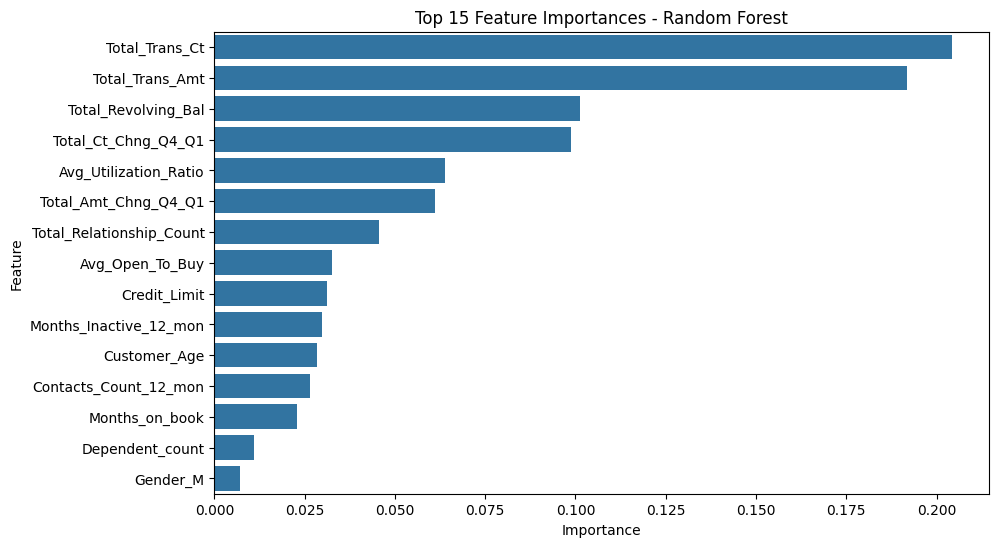

In [75]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Feature importance interpretation

The Random Forest feature importance highlights the variables that contribute the most to the model's predictions.

If the top variables are mainly related to transactions, inactivity, revolving balance, or customer contacts, this confirms the EDA findings: churn appears to be strongly associated with customer engagement and usage behavior.

Variables such as `Total_Trans_Ct`, `Total_Trans_Amt`, `Total_Revolving_Bal`, `Total_Ct_Chng_Q4_Q1`, `Months_Inactive_12_mon`, and `Contacts_Count_12_mon` are particularly important because they reflect how actively customers use their credit card and interact with the bank.

### Feature importance interpretation

The Random Forest feature importance highlights the variables that contribute the most to the model's predictions.

If the top variables are mainly related to transactions, inactivity, revolving balance, or customer contacts, this confirms the EDA findings: churn appears to be strongly associated with customer engagement and usage behavior.

Variables such as `Total_Trans_Ct`, `Total_Trans_Amt`, `Total_Revolving_Bal`, `Total_Ct_Chng_Q4_Q1`, `Months_Inactive_12_mon`, and `Contacts_Count_12_mon` are particularly important because they reflect how actively customers use their credit card and interact with the bank.

### Comparaison 

In [82]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest"],
    "accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "f1_score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "roc_auc": [
        roc_auc_score(y_test, y_proba_log),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

results

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.832675,0.486590,0.781538,0.599764,0.896723
1,Random Forest,0.949161,0.933594,0.735385,0.822719,0.984551
